# ipynb/cls_compare_nofont.ipynb - 分类结果对比(无字体) / Classification compare (no font)

## 项目背景 / Background
分类结果对比(无字体)
Classification compare (no font)

## 功能模块 / Modules
- 12 类分类结果的多模型对比
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: inference_*.py、ipynb/cls_compare_nofont_abla*.ipynb
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



Warning message:
“package ‘showtext’ was built under R version 4.3.3”
Loading required package: sysfonts



Warning message:
“package ‘sysfonts’ was built under R version 4.3.3”
Loading required package: showtextdb

Warning message:
“package ‘showtextdb’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘scales’ was built under R version 4.3.3”


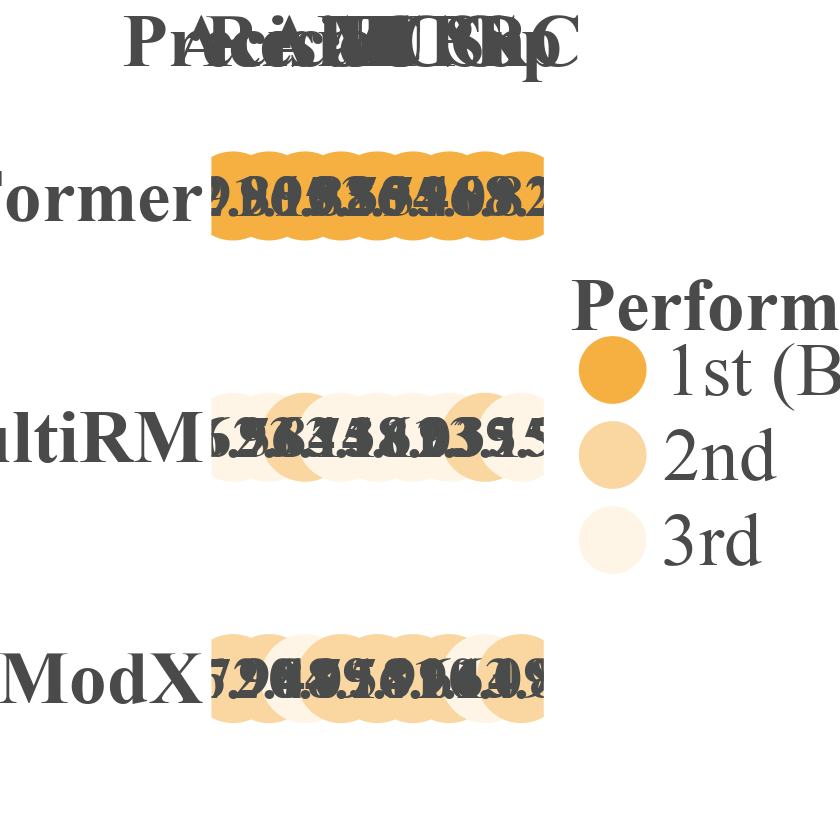

In [1]:
# 1. 安装并加载字体管理包
library(showtext)
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)

# 2. 注册Times New Roman (如路径不同请自行调整或使用系统默认)
tryCatch({
  font_add("Times New Roman", 
           regular = "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf", 
           bold = "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold.ttf")
  showtext_auto()
}, error = function(e) message("字体加载失败，使用默认字体"))

showtext_opts(dpi = 300)

# --- 1. 数据读取与计算平均值 ---
file_list <- list(
  "ModX" = "data/modx_res.csv",
  "MultiRM" = "data/multirm_res.csv",
  "RGCNFormer" = "data/res.csv"
)

metric_levels <- c("Acc", "Precision", "Recall", "AUC", "F1", "MCC", "AUPRC", "Sn", "Sp")

# 自动读取并计算均值
df_list <- lapply(names(file_list), function(mname) {
  read.csv(file_list[[mname]]) %>%
    summarise(across(all_of(metric_levels), \(x) mean(x, na.rm = TRUE))) %>%
    mutate(Model = mname)
})

# 合并数据并处理格式
plot_data <- bind_rows(df_list) %>%
  pivot_longer(cols = all_of(metric_levels), names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric = factor(Metric, levels = metric_levels),
    Model = factor(Model, levels = c("ModX", "MultiRM", "RGCNFormer")) # Y轴顺序
  ) %>%
  # 计算排名：在每个指标内部，Value最大的排名为1
  group_by(Metric) %>%
  mutate(Rank = rank(-Value, ties.method = "first")) %>% 
  ungroup() %>%
  mutate(Rank_Factor = factor(Rank, levels = c(1, 2, 3), labels = c("1st (Best)", "2nd", "3rd")))

# --- 2. 定义颜色深度 ---
rank_palette <- c(
  "1st (Best)" = "#F5B041",  # 明亮的翡翠绿 (比 #186A3B 浅，黑色字清晰)
  "2nd"        = "#FAD7A0",  # 中等浅绿
  "3rd"        = "#FEF5E7"   # 极浅绿
)
# rank_palette <- c(
#   "1st (Best)" = "#27AE60",  # 明亮的翡翠绿 (比 #186A3B 浅，黑色字清晰)
#   "2nd"        = "#82E0AA",  # 中等浅绿
#   "3rd"        = "#D5F5E3"   # 极浅绿
# )
rank_palette_C <- c(
  "TreeX"   = "#F5B041",  # 1st (Best)
  "ModX"    = "#FAD7A0",  # 2nd
  "MultiRM" = "#FEF5E7"   # 3rd
)

# --- 3. 绘图 ---
p1 <- ggplot() +
  # A. 绘制圆圈：大小映射 Value，颜色映射 Rank
  geom_point(data = plot_data, aes(x = Metric, y = Model, size = Value, color = Rank_Factor)) +
  
  # B. 绘制数值文本
  geom_text(data = plot_data, aes(x = Metric, y = Model, 
                                 label = sprintf("%.2f", Value * 100)), 
            size = 5, fontface = "bold", family = "Times New Roman", color = "#4A4B4B") +
  
  # 颜色映射设置
  scale_color_manual(name = "Performance Rank", values = rank_palette) +
  
  # 尺寸映射设置：添加guide = "none" 取消Average Value图例
  scale_size_continuous(
    name = "Average Value",
    range = c(24, 24),
    limits = c(0.35, 1),
    breaks = c(0.4, 0.6, 0.8, 1.0),
    labels = c("40%", "60%", "80%", "100%"),
    guide = "none"  # 核心：取消size对应的Average Value图例
  ) +
  
  # 辅助设置
  scale_x_discrete(position = "top", expand = expansion(add = c(0.6, 0.6))) +  # 增大 x 轴扩展范围
  scale_y_discrete(expand = expansion(add = c(0.6, 0.6))) +
  theme_minimal() +
  theme(
    text = element_text(family = "Times New Roman"),
    axis.text.x = element_text(size = 18, face = "bold", color = "#4A4A4A"),
    axis.text.y = element_text(size = 18, face = "bold", color = "#4A4A4A"),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_rect(fill = "white", color = NA),  # 纯白背景
    plot.background = element_rect(fill = "white", color = NA),   # 纯白背景
    legend.position = "right",
    legend.title = element_text(size = 18, face = "bold", color = "#4A4A4A"),
    legend.text = element_text(size = 18, color = "#4A4A4A"),
    plot.margin = margin(10, 10, 10, 10)
  ) +
  
  # --- 4. 核心修改：仅保留颜色图例的配置，删掉多余的size配置 ---
  guides(
    color = guide_legend(
    override.aes = list(size = 18),  # 核心：控制图例圆圈大小，原6→改8（按需调整）
    label.theme = element_text(size = 18),  # 核心：控制图例文字大小，原全局9→改11
    order = 1,  # 图例显示顺序（1为优先）
    title.theme = element_text(size = 18)  # 可选：单独控制图例标题文字大小
  )
  )

# --- 5. 保存图片 ---
ggsave("png3/cls_compare_nofont.pdf", p1, width = 12, height = 3, dpi = 300)
print(p1)